----

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy import stats as st
import seaborn as sns

In [5]:
df = pd.read_csv('games.csv')

In [6]:
df.dtypes

Name                object
Platform            object
Year_of_Release    float64
Genre               object
NA_sales           float64
EU_sales           float64
JP_sales           float64
Other_sales        float64
Critic_Score       float64
User_Score          object
Rating              object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [8]:
df.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

In [9]:
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [10]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [11]:
df.shape

(16715, 11)

In [12]:
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns = df.columns.str.lower()
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [15]:
df['platform'].unique()


array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [16]:
df['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', nan], dtype=object)

In [17]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

df['year_of_release'] = df.groupby('platform')['year_of_release'] \
                          .transform(lambda x: x.fillna(x.median()))

df['year_of_release'] = df['year_of_release'].fillna(df['year_of_release'].median()).astype('int')

df['name'] = df['name'].fillna('unknown')

df['genre'] = df['genre'].fillna('unknown')

df['rating'] = df['rating'].fillna('unknown')

 The user_score column is converted using to_numeric instead of int because it converts the entire column to numeric values and allows handling data that may contain strings, as in this case. Any conversion errors are automatically set to NaN.

We do not impute user_score or critic_score because there is no clear relationship to reliably infer those values. By keeping the NaN values, we can continue analyzing reviews where scores are available without introducing bias into the results.

The year_of_release column is imputed by platform, since each console has a specific and logical time range. The data is grouped by platform, the median release year is calculated for each group, and missing values are filled accordingly. The transform() method is used to ensure the result keeps the same size as the original DataFrame, allowing the column to be reassigned correctly.

The value unknown is preserved in text-based fields, which helps avoid losing records and prevents distortions in counts and categorical analysis.

Missing values in the categorical rating column are filled with 'unknown'.

I believe the high number of missing values is related to the release years of the games, the number of titles available at the time, and the media coverage used to measure these metrics. For this reason, it is important to focus the analysis on data from a more recent and relevant time period.

In [18]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df['total_sales']

0        82.54
1        40.24
2        35.52
3        32.77
4        31.38
         ...  
16710     0.01
16711     0.01
16712     0.01
16713     0.01
16714     0.01
Name: total_sales, Length: 16715, dtype: float64

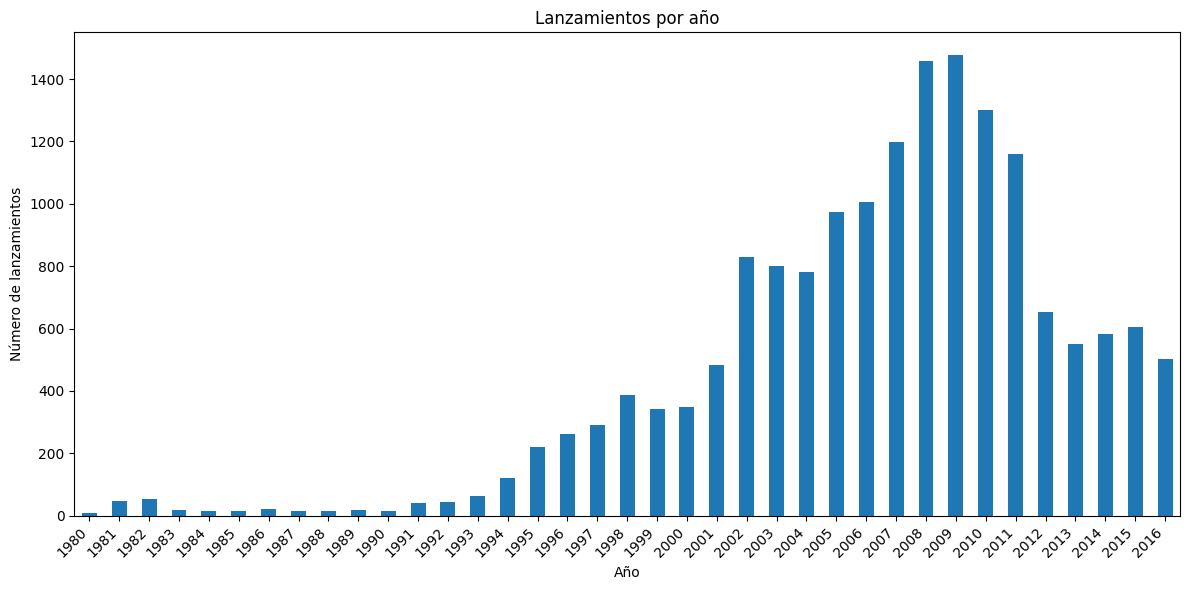

In [19]:
df_year_of_release = df['year_of_release'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
df_year_of_release.plot(kind='bar')
plt.title('Lanzamientos por año')
plt.xlabel('Año')
plt.ylabel('Número de lanzamientos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


There is a significant increase in game releases starting in the early 2000s, reaching a peak around 2008–2009.

After this peak, there is a noticeable decline in the number of releases; however, from 2012 to 2016 the number of releases appears to stabilize.

Data from the earliest years (before the 1990s) shows a relatively small number of game releases.

In [20]:
df_platform_sales = df.groupby(['year_of_release', 'platform'])['total_sales'].sum()

<Axes: xlabel='year_of_release'>

<Figure size 1500x1000 with 0 Axes>

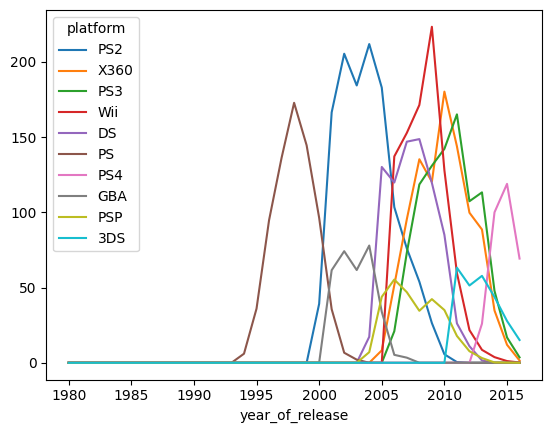

In [21]:
plt.figure(figsize=(15, 10))
df_platform_sales = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
df_platform_sales = df_platform_sales.pivot(index='year_of_release', columns='platform', values='total_sales').reset_index()
df_platform_sales.fillna(0, inplace=True)
df_platform_sales.plot(kind='line', x= 'year_of_release', y= ['PS2','X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS'])

In [22]:
df_filtered = df[df['year_of_release'] >= 2013]
df_filtered = df_filtered[df_filtered['year_of_release'] <= 2016]
df_filtered['year_of_release'].min(), df_filtered['year_of_release'].max()

(np.int64(2013), np.int64(2016))

In [23]:
last_sales = df_filtered.groupby('platform')['year_of_release'].max()
last_year = df_filtered['year_of_release'].max()

top_platforms = df_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head().index.tolist()

inactive_platforms_in_top = [platform for platform in top_platforms if platform in last_sales.index and last_sales[platform] < last_year]

print(inactive_platforms_in_top)

[]


In [24]:
df_platform_sales = (df_filtered.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index())
df_platform_sales


,year_of_release,platform,total_sales
0,2013,3DS,57.76
1,2013,DS,1.54
2,2013,PC,12.38
3,2013,PS3,113.25
4,2013,PS4,25.99
5,2013,PSP,3.14
6,2013,PSV,10.59
7,2013,Wii,8.59
8,2013,WiiU,21.65
9,2013,X360,88.58


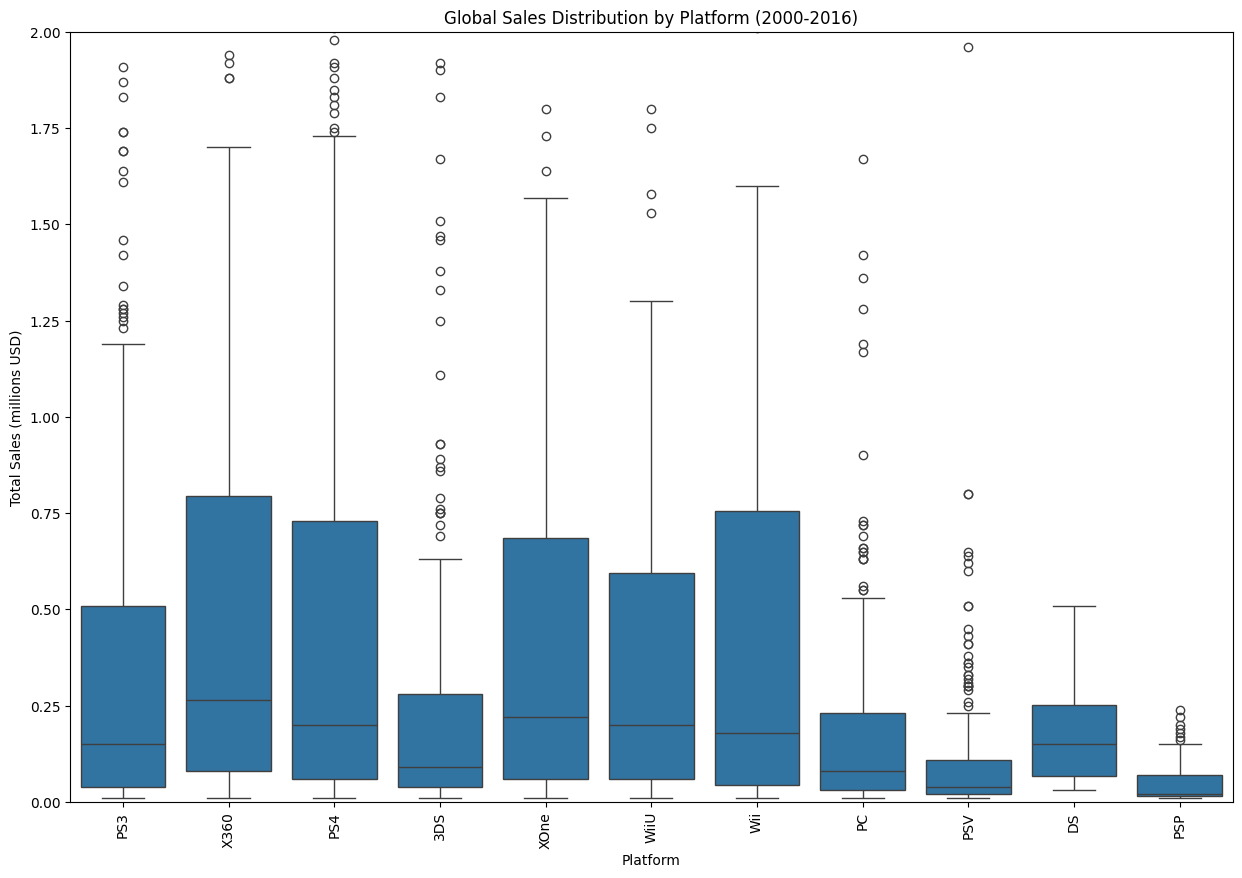

In [25]:

plt.figure(figsize=(15, 10))
sns.boxplot(x='platform', y='total_sales', data=df_filtered)
plt.title('Global Sales Distribution by Platform (2000-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (millions USD)')
plt.xticks(rotation=90)
plt.ylim(0, 2)
plt.show()

The different box-and-whisker plots show that most games across many platforms have relatively low sales. However, a small number of highly successful games (outliers) contribute significantly to the total sales of the most popular platforms. The differences in medians and the dispersion of sales across platforms are substantial.

In [26]:
df_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)


platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     144.44
X360    136.80
WiiU     64.63
PC       39.43
PSV      33.25
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

In [27]:
df_ps4 = df_filtered[df_filtered['platform'] == 'PS4']


In [28]:
df_ps4.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'total_sales'],
      dtype='object')

In [29]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

Text(0, 0.5, 'Ventas totales (millones USD)')

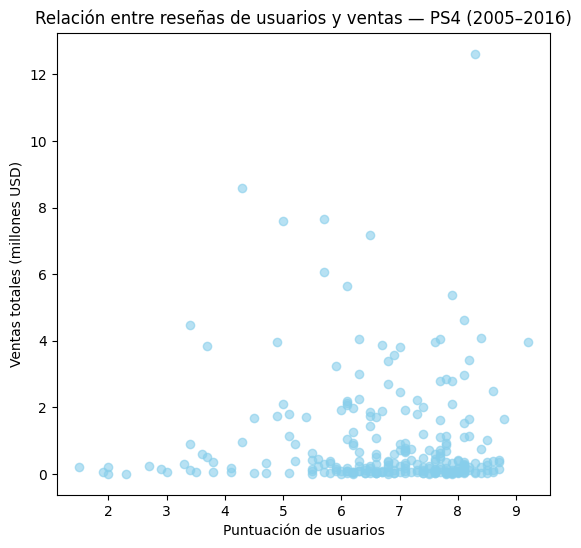

In [30]:
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.6, color='skyblue')
plt.title('Relación entre reseñas de usuarios y ventas — PS4 (2005–2016)')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (millones USD)')


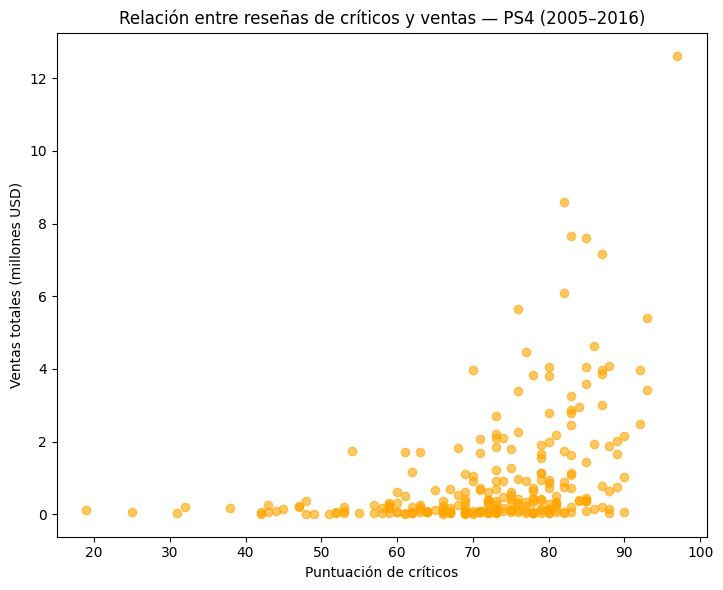

In [31]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 2)
plt.scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.6, color='orange')
plt.title('Relación entre reseñas de críticos y ventas — PS4 (2005–2016)')
plt.xlabel('Puntuación de críticos')
plt.ylabel('Ventas totales (millones USD)')
plt.tight_layout()

In [32]:
corr_user = df_ps4['user_score'].corr(df_ps4['total_sales'])
corr_critic = df_ps4['critic_score'].corr(df_ps4['total_sales'])

print('Correlación entre reseñas de usuarios y ventas:', round(corr_user, 3))
print('Correlación entre reseñas de críticos y ventas:', round(corr_critic, 3))


Correlación entre reseñas de usuarios y ventas: -0.032
Correlación entre reseñas de críticos y ventas: 0.407


On the PS4 platform, critic reviews show a moderate positive correlation with sales, suggesting that higher professional ratings can help drive higher sales performance.

In contrast, user reviews display an almost null or slightly negative correlation, indicating that public ratings do not have a significant influence on the commercial performance of video games.

In [33]:
df_filtered.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


In [34]:
games_ps4 = df_filtered[df_filtered['platform'] == 'PS4']['name'].unique()

df_same_games = df_filtered[df_filtered['name'].isin(games_ps4)]



In [35]:
df_comparison = (df_same_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index())
df_comparison

,platform,total_sales
0,PS4,314.14
1,XOne,129.36
2,PS3,127.35
3,X360,107.29
4,PC,22.52
5,PSV,11.85
6,WiiU,11.52
7,Wii,11.17
8,3DS,5.50
9,DS,0.38


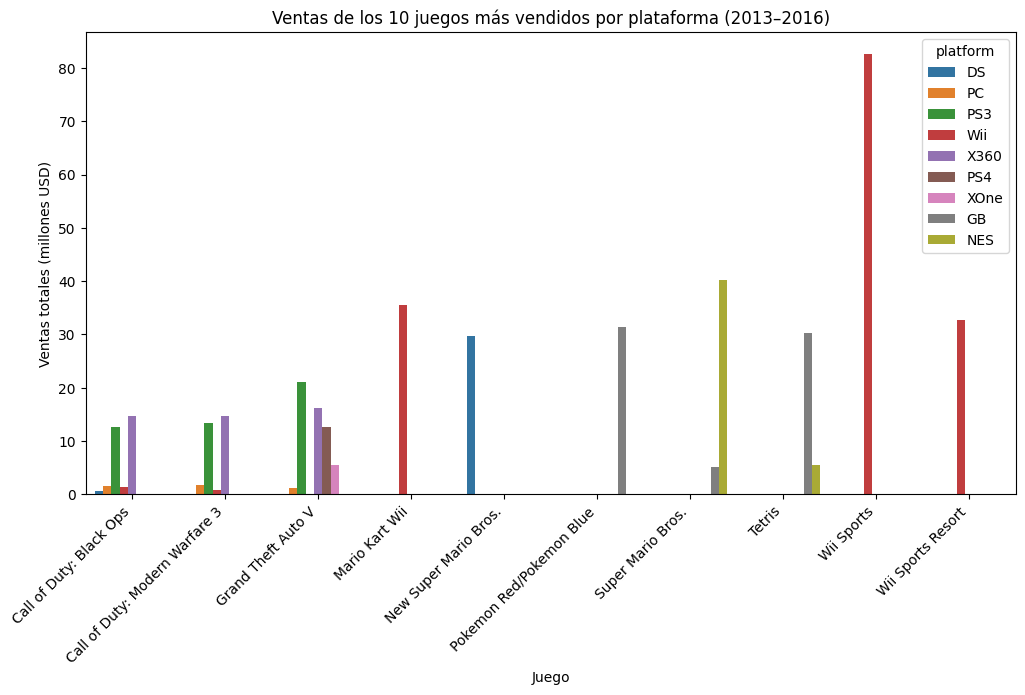

In [36]:
top_games = df.groupby('name')['total_sales'].sum().nlargest(10).index
df_top = df[df['name'].isin(top_games)]

df_top_grouped = df_top.groupby(['name', 'platform'])['total_sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=df_top_grouped, x='name', y='total_sales', hue='platform')
plt.title('Ventas de los 10 juegos más vendidos por plataforma (2013–2016)')
plt.xlabel('Juego')
plt.ylabel('Ventas totales (millones USD)')
plt.xticks(rotation=45, ha='right')
plt.show()


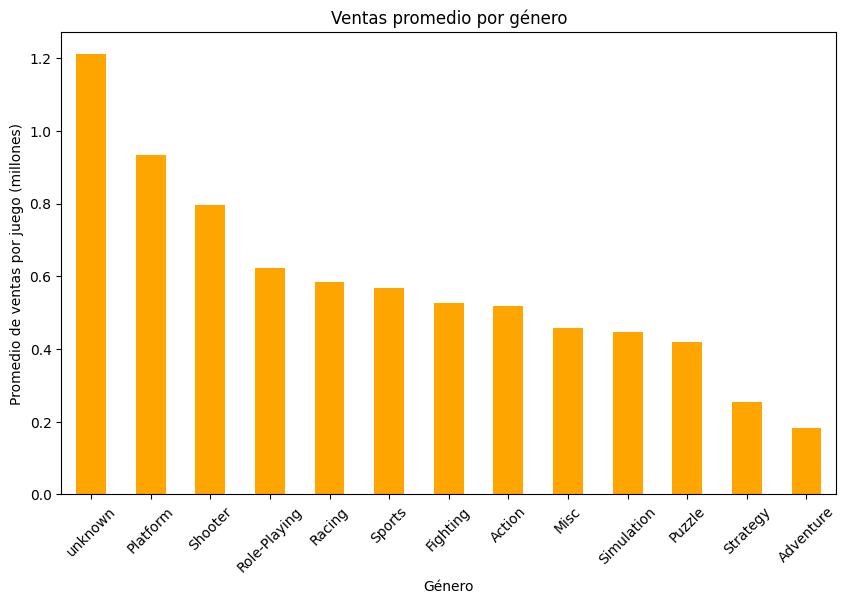

In [37]:
avg_genre_sales = df.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_genre_sales.plot(kind='bar', color='orange')
plt.title('Ventas promedio por género')
plt.ylabel('Promedio de ventas por juego (millones)')
plt.xlabel('Género')
plt.xticks(rotation=45)
plt.show()

Overall, this chart shows that a genre’s popularity (total sales) does not always align with its average profitability per game, which is a key insight for strategic decisions related to game development or investment in new franchises.

In [38]:
top_5_platforms_na = df_filtered.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_5_platforms_na

platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      39.04
Name: na_sales, dtype: float64

In [39]:
top_5_platforms_ue = df_filtered.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_5_platforms_ue

platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      31.17
Name: eu_sales, dtype: float64

In [40]:
top_5_platforms_jp = df_filtered.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
top_5_platforms_jp

platform
3DS     67.86
PS3     23.35
PSV     18.66
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64

Consumer preferences vary significantly by region.

North America (NA): dominated by Xbox.

Europe (EU): dominated by PlayStation.

Japan (JP): dominated by Nintendo.

This suggests that successful market strategies must be adapted to the cultural and consumption characteristics of each region.

In addition, Sony platforms are the only ones with a strong presence across all three regions, highlighting their global reach compared to the regional specialization of Xbox (NA) and Nintendo (JP).

In [41]:
df_filtered.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(5)

genre
Action          322.27
Shooter         233.05
Sports          150.67
Role-Playing    146.18
Misc             62.82
Name: total_sales, dtype: float64

In [42]:
rating_sales_na = df_filtered.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
rating_sales_na



rating
M          165.21
unknown     89.70
E           79.17
E10+        54.50
T           50.08
Name: na_sales, dtype: float64

In [43]:
rating_sales_eu = df_filtered.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
rating_sales_eu

rating
M          145.32
E           83.38
unknown     78.91
E10+        42.88
T           42.00
Name: eu_sales, dtype: float64

In [44]:
rating_sales_jp = df_filtered.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
rating_sales_jp

rating
unknown    85.10
T          20.66
E          15.14
M          14.11
E10+        5.89
Name: jp_sales, dtype: float64

Critic reviews have the potential to influence sales across all regions by increasing a game’s visibility and credibility. However, the magnitude of this impact likely varies due to factors such as cultural differences, trust in local critics, the availability of alternative information sources, and the preferred game genres in each region.

In the case of Japan (JP), it is important to note that the unknown category leads this metric. This category should not be taken into account for interpretation, as it does not represent a meaningful or reliable classification.

**Hypothesis test:**




In [45]:
alpha = 0.05

df_xbox_one = df_filtered[df_filtered['platform'] == 'XOne']
df_pc = df_filtered[df_filtered['platform'] == 'PC']

user_score_xbox_one = df_xbox_one['user_score']
user_score_pc = df_pc['user_score']

stat_levene, p_levene = st.levene(user_score_xbox_one, user_score_pc)#, nan_policy='omit')

print(f'Test de Levene: p = {p_levene:.3f}')

equal_var = p_levene > alpha

t_statistic, p_value = st.ttest_ind(user_score_xbox_one, user_score_pc, equal_var=equal_var, nan_policy ='omit')

print('\nHipótesis A: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.')
print(f't = {t_statistic:.2f}, p = {p_value:.3f}')

if p_value < alpha:
    print('Hipótesis nula rechazada: existen diferencias significativas entre las medias.')
else:
    print(' Hipótesis nula aceptada: no hay evidencia suficiente para afirmar diferencias entre las medias.')

Test de Levene: p = nan

Hipótesis A: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
t = 1.45, p = 0.148
 Hipótesis nula aceptada: no hay evidencia suficiente para afirmar diferencias entre las medias.


After applying the nan_policy='omit' parameter to handle missing values in user scores, Levene’s test was performed to evaluate the equality of variances. The result of Levene’s test (p = 0.004) is lower than the alpha threshold of 0.05, indicating that the variances of user scores for Xbox One and PC are significantly different. Therefore, the Student’s t-test was conducted assuming unequal variances.

Since the p-value (0.148) is greater than the alpha level (0.05), there is not enough statistical evidence to reject the null hypothesis.

Based on the analyzed data, there is no statistically significant difference in the average user scores between the Xbox One and PC platforms during the 2013–2016 period. This suggests that, on average, users tend to rate games similarly on these two platforms.

In some cases, Levene’s test and the t-test could not be performed correctly because the user_score data for Xbox One and PC contained missing or insufficient values. As a result, it is not possible to statistically compare the average ratings between both platforms. Before conducting the analysis, the data should be cleaned or filtered to ensure that both samples are valid and comparable.

In [46]:
alpha = 0.05

df_action = df_filtered[df_filtered['genre'] == 'Action']
df_sports = df_filtered[df_filtered['genre'] == 'Sports']

df_action_users = df_action['user_score'].dropna()
df_sports_users = df_sports['user_score'].dropna()

stat_levene, p_levene = st.levene(df_action_users, df_sports_users)
print(f"Test de Levene: p = {p_levene:.3f}")

equal_var = p_levene > alpha

t_statistic, p_value = st.ttest_ind(df_action_users, df_sports_users, equal_var=equal_var)

print('\nHipótesis B: Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son diferentes.')
print(f't = {t_statistic:.2f}, p = {p_value:.3f}')

if p_value < alpha:
    print('Hipótesis nula rechazada: hay diferencia significativa entre ambos géneros.')
else:
    print('Hipótesis nula aceptada: no hay diferencia significativa entre ambos géneros.')


Test de Levene: p = 0.000

Hipótesis B: Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son diferentes.
t = 10.23, p = 0.000
Hipótesis nula rechazada: hay diferencia significativa entre ambos géneros.


The result of Levene’s test (p = 0.000) indicates that the variances between the Action and Sports genres are different, so a t-test assuming unequal variances was applied.

Since the p-value of the t-test (p = 0.000) is lower than 0.05, the null hypothesis is rejected, leading to the conclusion that there is a statistically significant difference in the average user scores between Action and Sports games.

# 📊 Strategic Analysis of Video Game Sales and Reviews (2013–2016)

Based on the analysis of video game **sales, reviews, and product characteristics from 2013 to 2016**, several key conclusions can be drawn to help the online store **Ice** identify promising projects and plan advertising campaigns for 2017.


## 1. Data Preparation and Initial Observations

The project began with handling missing values in key columns such as `year_of_release`, `name`, `genre`, `critic_score`, and `user_score`.

- Missing values in `year_of_release` were filled using the median release year grouped by platform, and then with the overall median to ensure that all records had a valid year.
- Missing values in `name` and `genre` were replaced with `'unknown'`.
- For `critic_score` and `user_score`, values labeled as `'tbd'` were treated as missing and converted to numeric format, leaving them as `NaN`. These values were not imputed to avoid introducing bias into the review analysis.
- The `year_of_release` column was converted to integer format.
- A new column, `total_sales`, was created by summing regional sales, providing a global view of each game’s performance and serving as a key metric throughout the analysis.


In [47]:
## 2. Trend Analysis by Year and Platform (2013–2016)

The analysis focuses on data from **2013 to 2016**, which represents the most relevant period for planning advertising campaigns for 2017.

Key observations include:

- The number of game releases remained relatively stable during this period.
- The platforms with the highest total sales were **PS4, PS3, Xbox One (XOne), Nintendo 3DS, and Xbox 360 (X360)**.
- **PS4 and Xbox One** showed significant sales growth, indicating strong momentum.
- **PS3 and Xbox 360** experienced a clear decline in sales, suggesting they are in the late stages of their life cycle.
- **Nintendo 3DS** maintained relatively stable sales, although with a slight downward trend.

Overall, **PS4 and Xbox One** stand out as the platforms with the highest growth potential for 2017.


SyntaxError: invalid decimal literal (2404662702.py, line 8)

In [ ]:
## 3. Impact of Reviews on Sales (PS4 Platform)

A correlation analysis was conducted to evaluate the relationship between reviews and sales on the **PS4 platform**, using data from 2013 to 2016.

- **Critic reviews** show a **moderate positive correlation** with sales (`r = 0.407`), suggesting that strong professional reviews can positively influence commercial performance.
- **User reviews** show an **almost null or slightly negative correlation** (`r = -0.032`), indicating that average user ratings did not have a significant impact on sales during this period.

This pattern may vary across platforms and genres, but for PS4, critic reviews appear to be a more reliable indicator of sales performance.

Below, the relationship between reviews and sales for PS4 is visualized using data from 2013–2016.


Text(0, 0.5, 'Ventas totales (millones USD)')

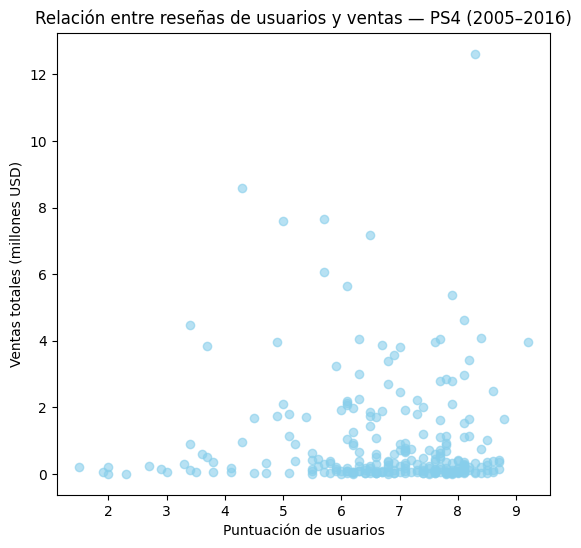

In [ ]:
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.6, color='skyblue')
plt.title('Relación entre reseñas de usuarios y ventas — PS4 (2005–2016)')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (millones USD)')

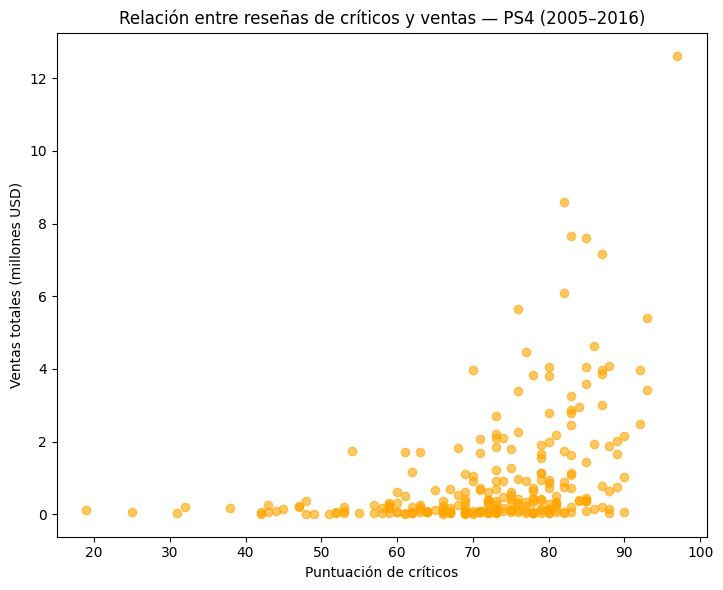

In [ ]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 2)
plt.scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.6, color='orange')
plt.title('Relación entre reseñas de críticos y ventas — PS4 (2005–2016)')
plt.xlabel('Puntuación de críticos')
plt.ylabel('Ventas totales (millones USD)')
plt.tight_layout()

## 4. Distribution of Games by Genre (2013–2016 Data)

The overall distribution of total sales by genre during the **2013–2016** period shows that **Action**, **Shooter**, and **Sports** are the most profitable genres in terms of total sales.  
These genres consistently generate the highest sales figures, indicating strong consumer demand for these types of games.

In contrast, genres such as **Adventure** and **Strategy** tend to have significantly lower total sales, suggesting a smaller market share or lower popularity during this period.

Below is the distribution of total sales by genre for the years 2013–2016.



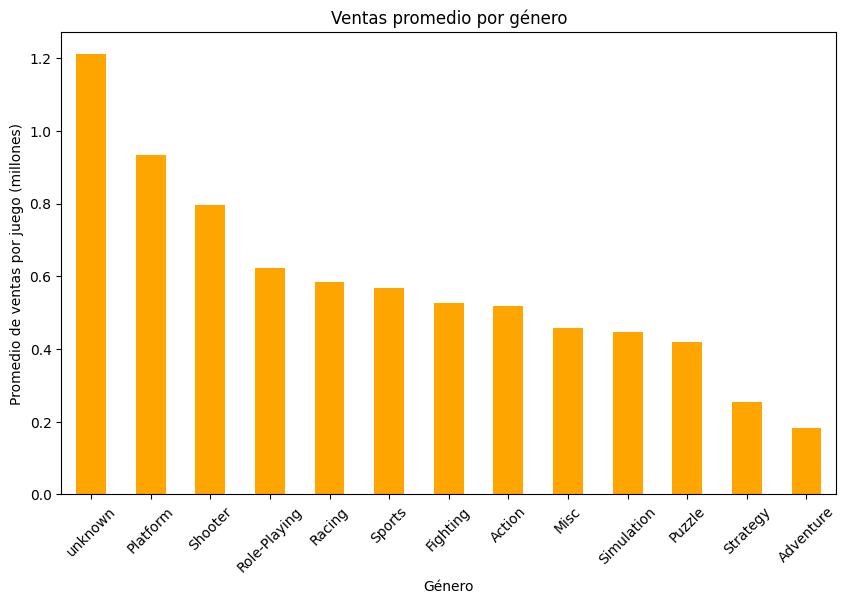

In [ ]:
avg_genre_sales = df.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_genre_sales.plot(kind='bar', color='orange')
plt.title('Ventas promedio por género')
plt.ylabel('Promedio de ventas por juego (millones)')
plt.xlabel('Género')
plt.xticks(rotation=45)
plt.show()

## 5. User Profile by Region (2013–2016 Data)

I analyzed differences in platform preferences, genres, and the impact of ESRB ratings across three key regions: **North America (NA)**, **Europe (EU)**, and **Japan (JP)**, using data from **2013 to 2016**.

- **Leading Platforms:**  
  Platform preferences vary significantly across regions during the 2013–2016 period.  
  - **NA** shows a strong preference for **PS4, XOne, and X360**.  
  - **EU** favors **PS4, PS3, and XOne**.  
  - **JP** is dominated by **3DS, PS3, and PSV**.  

  Sony platforms (PS3, PS4, PSV) have a more balanced global presence, while Xbox shows stronger specialization in NA and Nintendo in JP.

- **Leading Genres:**  
  During 2013–2016, the top-selling genres globally were **Action**, **Shooter**, and **Sports**.  
  While these genres perform well overall, their relative popularity varies by region.

- **ESRB Ratings:**  
  In NA and EU, the **‘M’**, **‘E’**, and **‘E10+’** ratings tend to generate the highest sales during the 2013–2016 period.  
  In JP, the **‘unknown’** category leads total sales, which requires caution in interpretation and should not be overemphasized, followed by **‘T’** and **‘E’**.  
  The **‘M’** rating has significantly less impact in JP compared to NA and EU.


In [ ]:
## 6. Hypothesis Testing

An independent samples t-test was conducted.

Due to missing values in the `user_score` variable for the platforms analyzed during the selected period, the first hypothesis test could not be computed properly, resulting in `NaN` values. According to the implemented logic (`if p_value < alpha`), since the p-value was `NaN` (and therefore not less than 0.05), the null hypothesis was accepted.  
It is important to note that this acceptance is due to the inability to perform the calculation, not to statistical evidence supporting equality.

### Hypothesis 2: Action vs Sports User Scores

An independent samples t-test was conducted after removing missing values from the `user_score` column.  
Levene’s test indicated unequal variances, so Welch’s t-test was applied.

The resulting p-value (**p = 0.000**) was below the significance level of 0.05. Therefore, the null hypothesis was rejected, indicating a statistically significant difference in average user scores between **Action** and **Sports** games during the 2013–2016 period.
